## Peak Ground Velocity (PGV) estimation
@Sabrina Keil (LMU Munich)

The DIN 4150 Part 3 is a German standard that provides guidelines for assessing the effects of ground vibrations caused by human activities. In terms of induced seismicity, DIN 4150 Part 3 specifies allowable ground motion limits based on the type of structure and its sensitivity to vibration. These limits are expressed in terms of peak ground velocity (PGV), which is a measure of the maximum ground motion experienced during an event. In general for ground motions below 5 mm/s damage to buildings is unlikely. In the case of induced seismicity, if ground motion exceeding 5 mm/s in the frequency range of 1-10 Hz occurs, affected areas must be assessed, and geothermal operators may be required to compensate for damages.

<figure>
  <IMG SRC="./Figures/DIN.png" WIDTH=500 ALIGN="center">
</figure>

In the following tutorial we will calculate PGV values that were recorded at three different stations for a ML 1.4 and ML 1.8 induced event near the geothermal power plant of Unterhaching. We will see if the events exceeded the threshold of 5 mm/s.

<figure>
  <IMG SRC="./Figures/MAP_stations_UH.png" WIDTH=600 ALIGN="center">
</figure>

In [2]:
#import required packages
#import required packages
from obspy import UTCDateTime, read_inventory, read, Stream
import matplotlib.pyplot as plt
import numpy as np
from obspy.clients.fdsn import Client

client = Client("EIDA")

## 1) Event ML 1.4

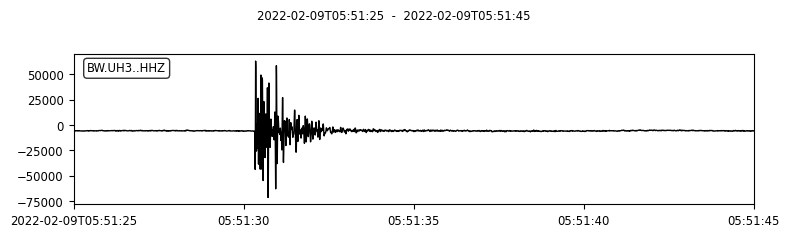

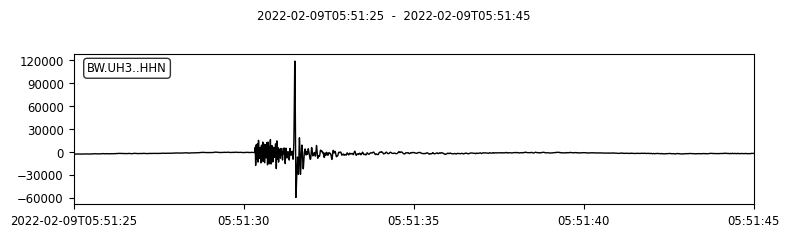

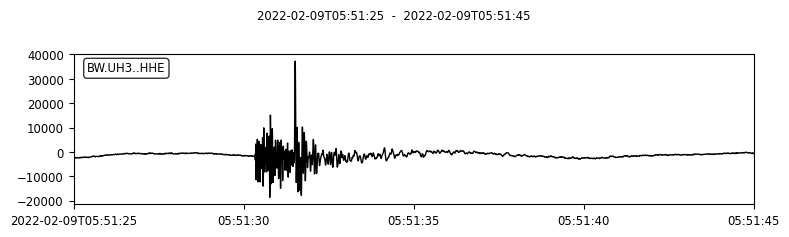

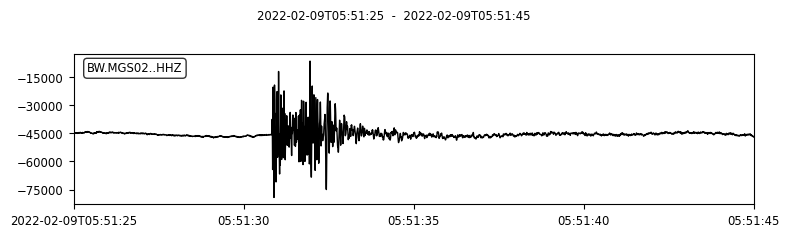

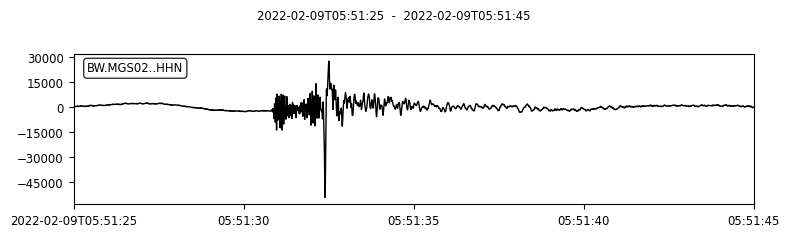

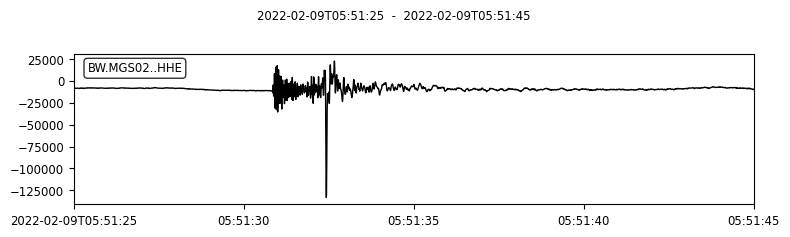

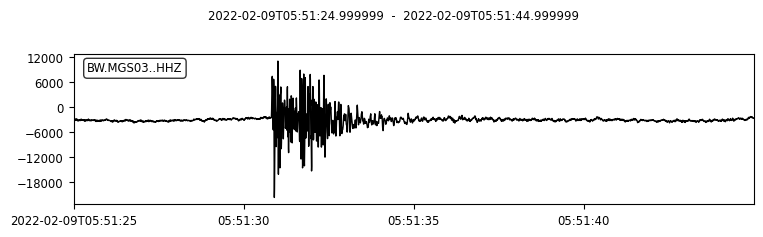

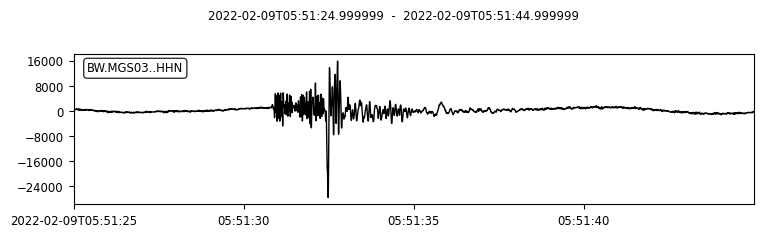

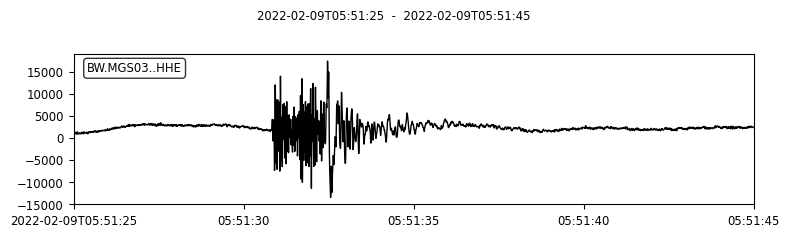

In [5]:
#import data
#import seismograms
t = UTCDateTime("2022-02-09T05:51:25.000")
UH3_Z = client.get_waveforms("BW", "UH3", "", "HHZ", t, t + 20)
UH3_N = client.get_waveforms("BW", "UH3", "", "HHN", t, t + 20)
UH3_E = client.get_waveforms("BW", "UH3", "", "HHE", t, t + 20)

MGS02_Z = client.get_waveforms("BW", "MGS02", "", "HHZ", t, t + 20)
MGS02_N = client.get_waveforms("BW", "MGS02", "", "HHN", t, t + 20)
MGS02_E = client.get_waveforms("BW", "MGS02", "", "HHE", t, t + 20)

MGS03_Z = client.get_waveforms("BW", "MGS03", "", "HHZ", t, t + 20)
MGS03_N = client.get_waveforms("BW", "MGS03", "", "HHN", t, t + 20)
MGS03_E = client.get_waveforms("BW", "MGS03", "", "HHE", t, t + 20)

#plot data

UH3_Z.plot()
UH3_N.plot()
UH3_E.plot()

MGS02_Z.plot()
MGS02_N.plot()
MGS02_E.plot()

MGS03_Z.plot()
MGS03_N.plot()
MGS03_E.plot()

plt.show()

In [6]:
st_UH3=Stream([UH3_Z[0].copy(),UH3_N[0].copy(),UH3_E[0].copy()])
st_MGS02=Stream([MGS02_Z[0].copy(),MGS02_N[0].copy(),MGS02_E[0].copy()])
st_MGS03=Stream([MGS03_Z[0].copy(),MGS03_N[0].copy(),MGS03_E[0].copy()])

In [7]:
#preprocessing of the data 

#load inventory

inv_UH3=client.get_stations(network="BW", station="UH3",
    channel="HH*", level="response")
print(inv_UH3)

inv_MGS02=client.get_stations(network="BW", station="MGS02",
    channel="HH*", level="response")
print(inv_MGS02)

inv_MGS03=client.get_stations(network="BW", station="MGS03",
    channel="HH*", level="response")
print(inv_MGS03)

Inventory created at 2024-05-16T16:12:55.202736Z
	Sending institution: EIDA-Federator (EIDA)
	Contains:
		Networks (1):
			BW
		Stations (1):
			BW.UH3 (Taufkirchen, MAGS2, BW-Net)
		Channels (3):
			BW.UH3..HHZ, BW.UH3..HHN, BW.UH3..HHE
Inventory created at 2024-05-16T16:12:55.602776Z
	Sending institution: EIDA-Federator (EIDA)
	Contains:
		Networks (1):
			BW
		Stations (2):
			BW.MGS02 (Perlacher Forst, MAGS2, BW-Net)
			BW.MGS02 (PerlachForst,MAGS2,BW-Net)
		Channels (6):
			BW.MGS02..HHZ (2x), BW.MGS02..HHN (2x), BW.MGS02..HHE (2x)
Inventory created at 2024-05-16T16:12:56.018502Z
	Sending institution: EIDA-Federator (EIDA)
	Contains:
		Networks (1):
			BW
		Stations (2):
			BW.MGS03 (Putzbrunn, MAGS2, BW-Net)
			BW.MGS03 (WaldPutzbrunn,MAGS2, BW-Net)
		Channels (6):
			BW.MGS03..HHZ (2x), BW.MGS03..HHN (2x), BW.MGS03..HHE (2x)


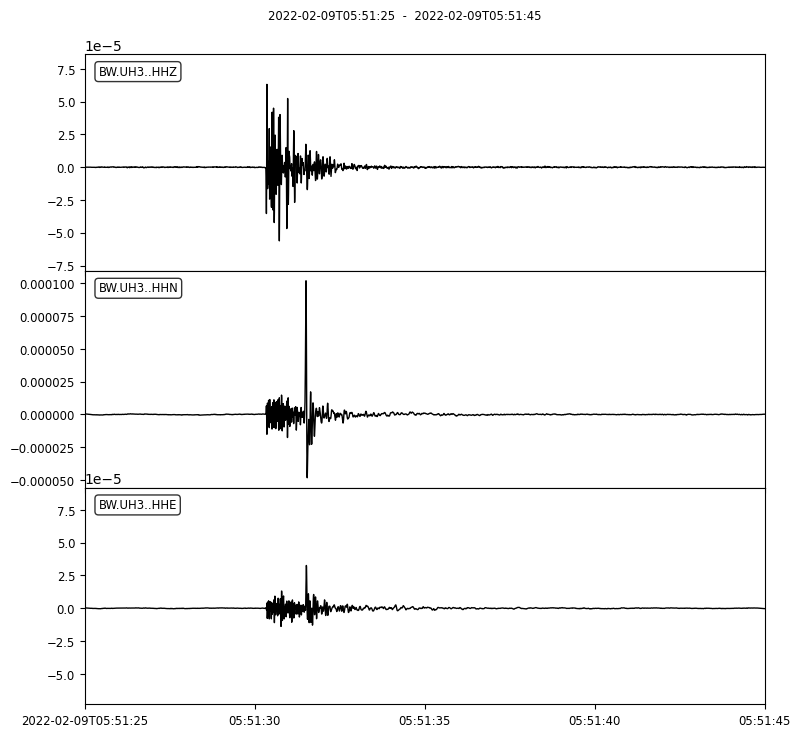

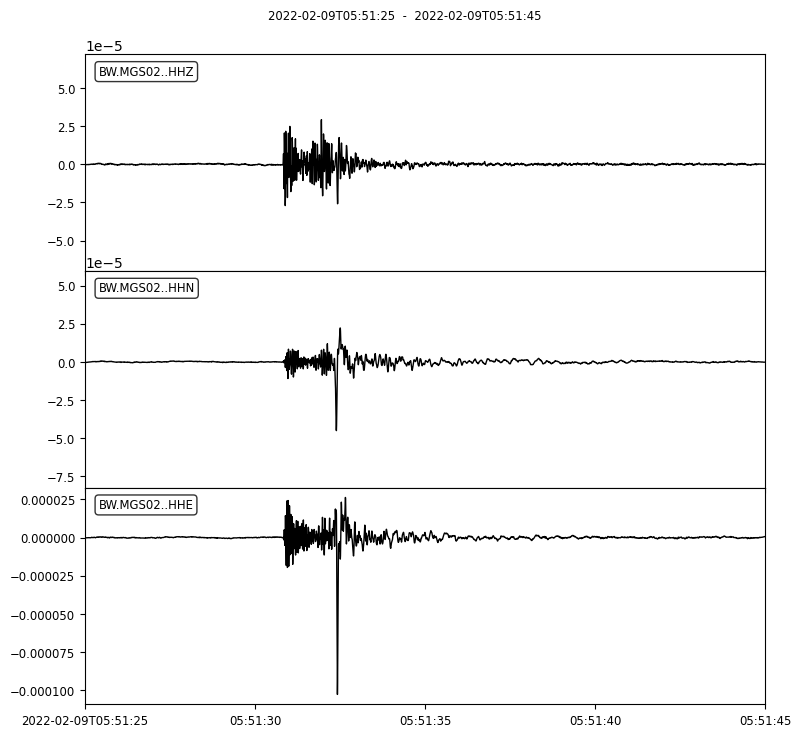

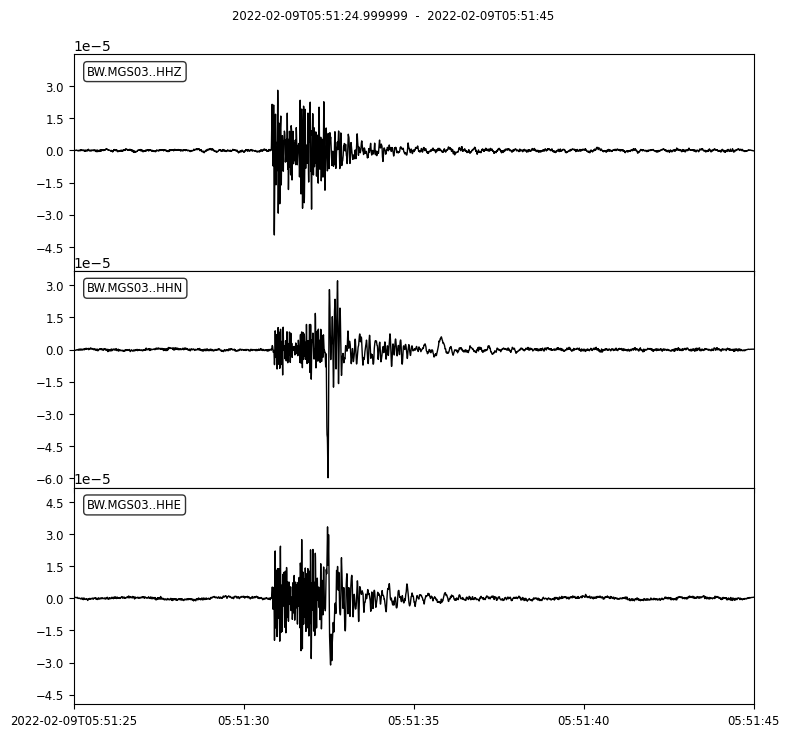

In [8]:
#preprocessing
       
#remove instrument response
st_UH3.remove_response(inventory=inv_UH3,output="VEL",water_level=False)
st_MGS02.remove_response(inventory=inv_MGS02,output="VEL",water_level=False)
st_MGS03.remove_response(inventory=inv_MGS03,output="VEL",water_level=False)

st_UH3.detrend('spline', order= 3, dspline=500)    
st_MGS02.detrend('spline', order= 3, dspline=500)
st_MGS03.detrend('spline', order= 3, dspline=500)


st_UH3.detrend("demean")
st_MGS02.detrend("demean")
st_MGS03.detrend("demean")


st_UH3.plot()
st_MGS02.plot()
st_MGS03.plot()

plt.show()

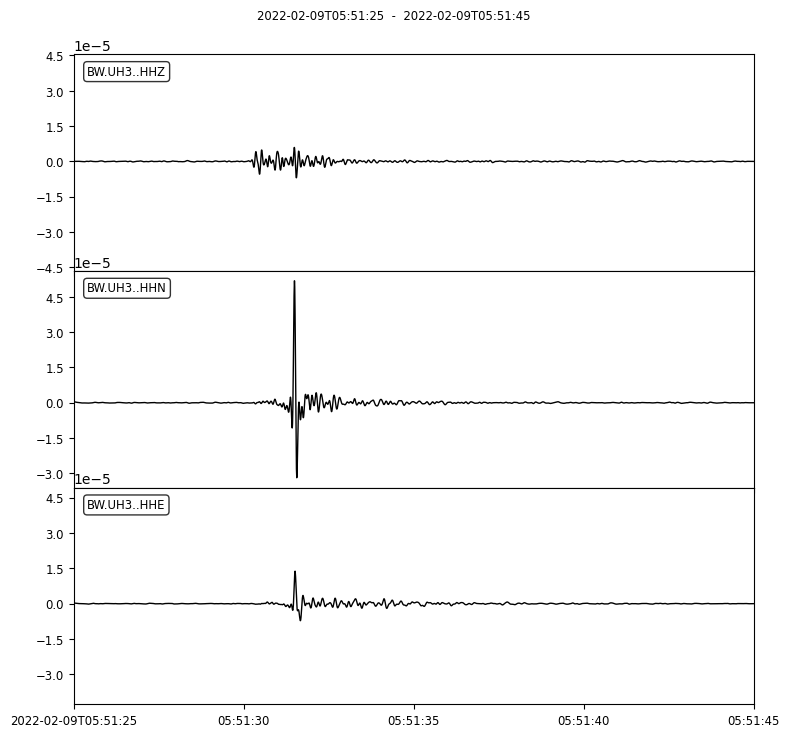

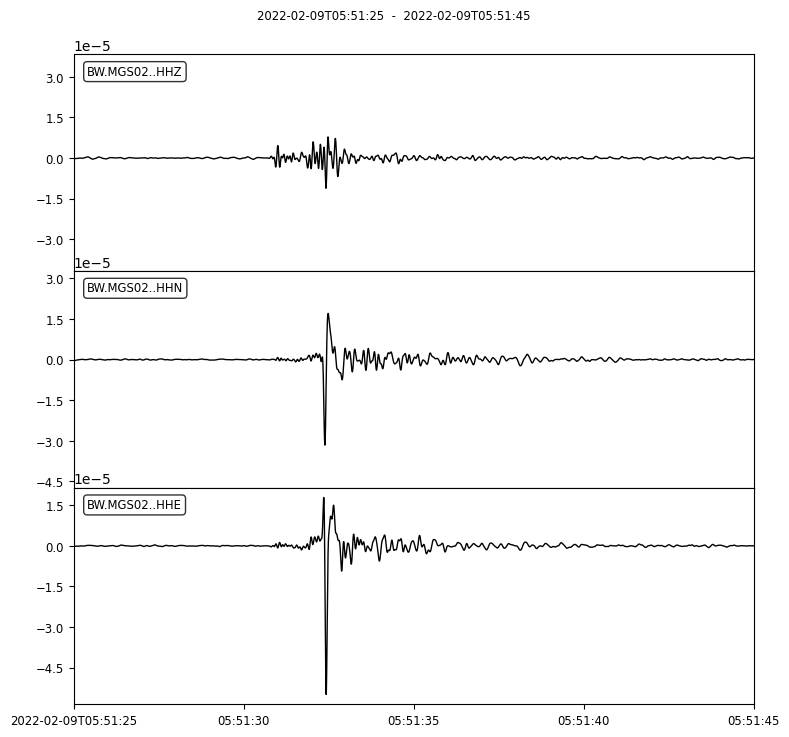

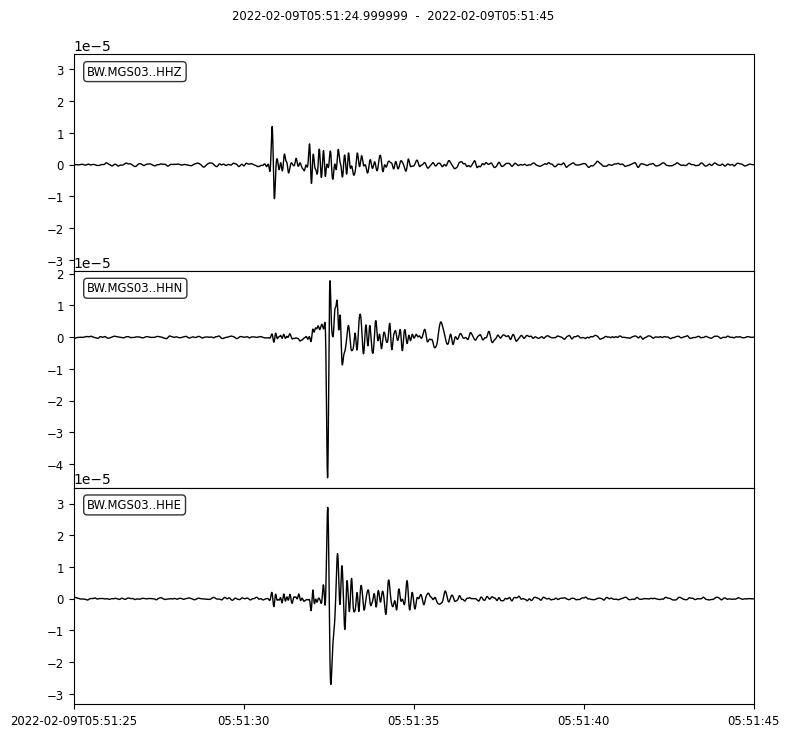

In [9]:
#Filter seismograms according to the DIN4150

freqmin=1
freqmax=10

UH3=st_UH3.copy().filter('bandpass', freqmin=freqmin,freqmax=freqmax, corners=4, zerophase=True)
MGS02=st_MGS02.copy().filter('bandpass', freqmin=freqmin,freqmax=freqmax, corners=4, zerophase=True)
MGS03=st_MGS03.copy().filter('bandpass', freqmin=freqmin,freqmax=freqmax, corners=4, zerophase=True)


UH3.plot()
MGS02.plot()
MGS03.plot()
plt.show()

In [10]:
#compute PGV value for each station

PGV_UH3=[]
for n in range(len(UH3)):
    PGV=max(abs(UH3[n].data))
    PGV_UH3.append(PGV)
    
print("The PGV values for UH3 are:", PGV_UH3, "m/s")

PGV_MGS02=[]
for n in range(len(MGS02)):
    PGV=max(abs(MGS02[n].data))
    PGV_MGS02.append(PGV)
    
print("The PGV values for MGS02 are:", PGV_MGS02, "m/s")

PGV_MGS03=[]
for n in range(len(MGS03)):
    PGV=max(abs(MGS03[n].data))
    PGV_MGS03.append(PGV)
    
print("The PGV values for MGS03 are:", PGV_MGS03, "m/s")


The PGV values for UH3 are: [6.963979819178575e-06, 5.180842632432927e-05, 1.3796437418675186e-05] m/s
The PGV values for MGS02 are: [1.1173803947393222e-05, 3.15901860087773e-05, 5.487733956413967e-05] m/s
The PGV values for MGS03 are: [1.2004643995970946e-05, 4.4302970651217216e-05, 2.8763878788661736e-05] m/s


In [11]:
#To compare it to the DIN we have to compute the root-mean-square value from the horizontal components

rms_UH3=np.sqrt((PGV_UH3[1]**2 + PGV_UH3[2]**2)/2)
print("UH3:", rms_UH3*1000, "mm/s")

rms_MGS02=np.sqrt((PGV_MGS02[1]**2 + PGV_MGS02[2]**2)/2)
print("MGS02:", rms_MGS02*1000, "mm/s")

rms_MGS03=np.sqrt((PGV_MGS03[1]**2 + PGV_MGS03[2]**2)/2)
print("MGS03:", rms_MGS03*1000, "mm/s")


UH3: 0.03791078160399014 mm/s
MGS02: 0.04477422388890196 mm/s
MGS03: 0.03735046138598183 mm/s


At none of the stations the PGV values exceeded 5 mm/s.

## 1) Event ML 1.8

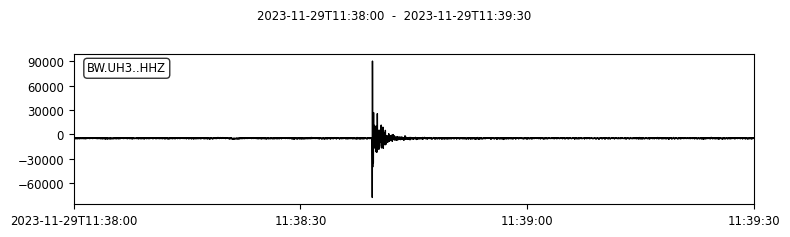

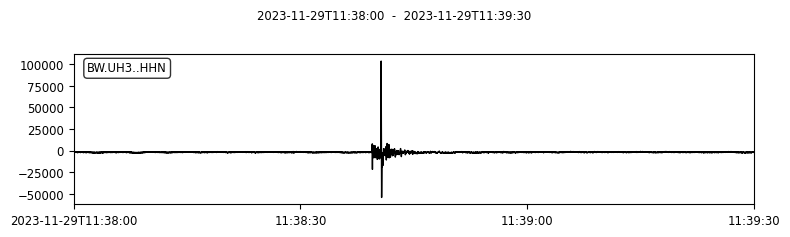

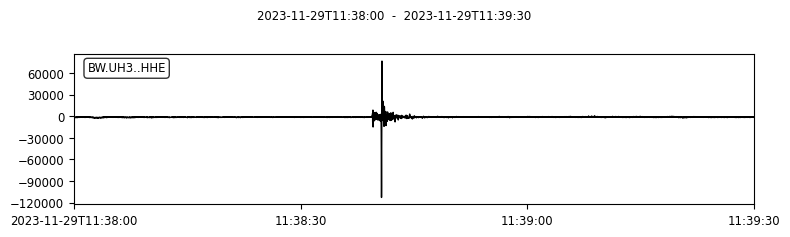

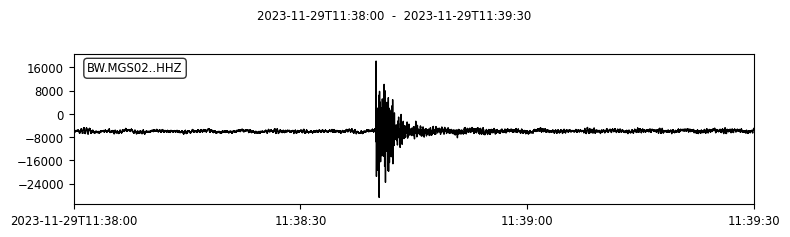

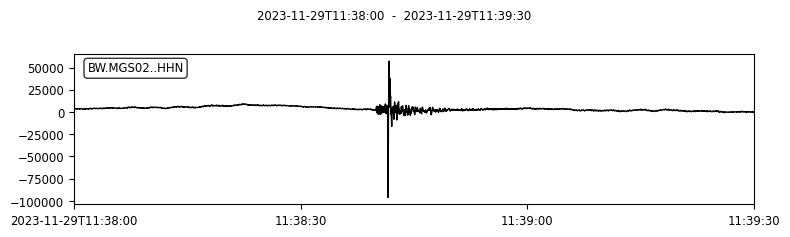

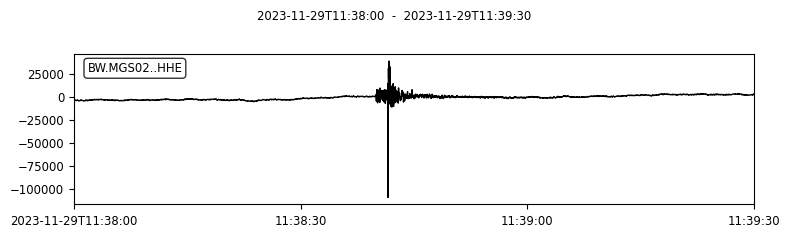

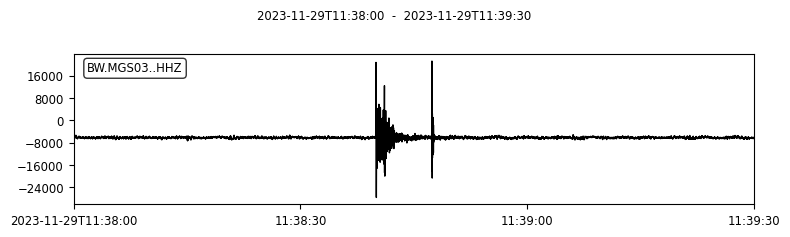

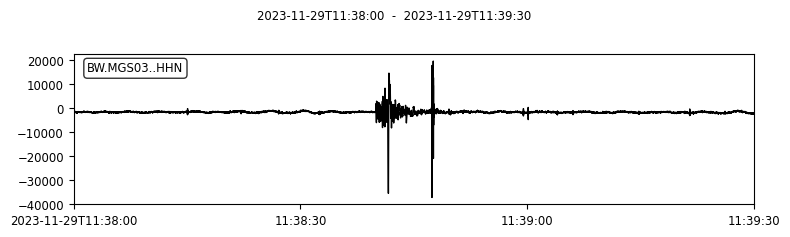

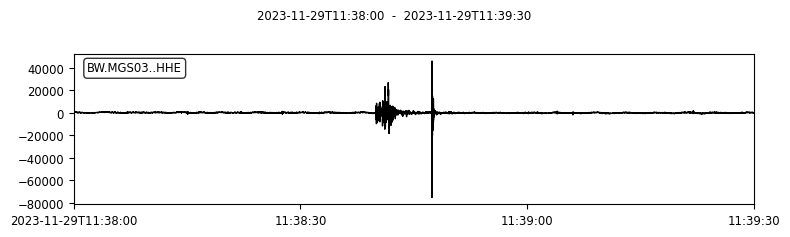

In [12]:
#import data
#import seismograms
t = UTCDateTime("2023-11-29T11:38:00.000")
UH3_Z = client.get_waveforms("BW", "UH3", "", "HHZ", t, t + 90)
UH3_N = client.get_waveforms("BW", "UH3", "", "HHN", t, t + 90)
UH3_E = client.get_waveforms("BW", "UH3", "", "HHE", t, t + 90)

MGS02_Z = client.get_waveforms("BW", "MGS02", "", "HHZ", t, t + 90)
MGS02_N = client.get_waveforms("BW", "MGS02", "", "HHN", t, t + 90)
MGS02_E = client.get_waveforms("BW", "MGS02", "", "HHE", t, t + 90)

MGS03_Z = client.get_waveforms("BW", "MGS03", "", "HHZ", t, t + 90)
MGS03_N = client.get_waveforms("BW", "MGS03", "", "HHN", t, t + 90)
MGS03_E = client.get_waveforms("BW", "MGS03", "", "HHE", t, t + 90)

#plot data

UH3_Z.plot()
UH3_N.plot()
UH3_E.plot()

MGS02_Z.plot()
MGS02_N.plot()
MGS02_E.plot()

MGS03_Z.plot()
MGS03_N.plot()
MGS03_E.plot()

plt.show()

In [18]:
st_UH3=Stream([UH3_Z[0].copy(),UH3_N[0].copy(),UH3_E[0].copy()])
st_MGS02=Stream([MGS02_Z[0].copy(),MGS02_N[0].copy(),MGS02_E[0].copy()])
st_MGS03=Stream([MGS03_Z[0].copy(),MGS03_N[0].copy(),MGS03_E[0].copy()])

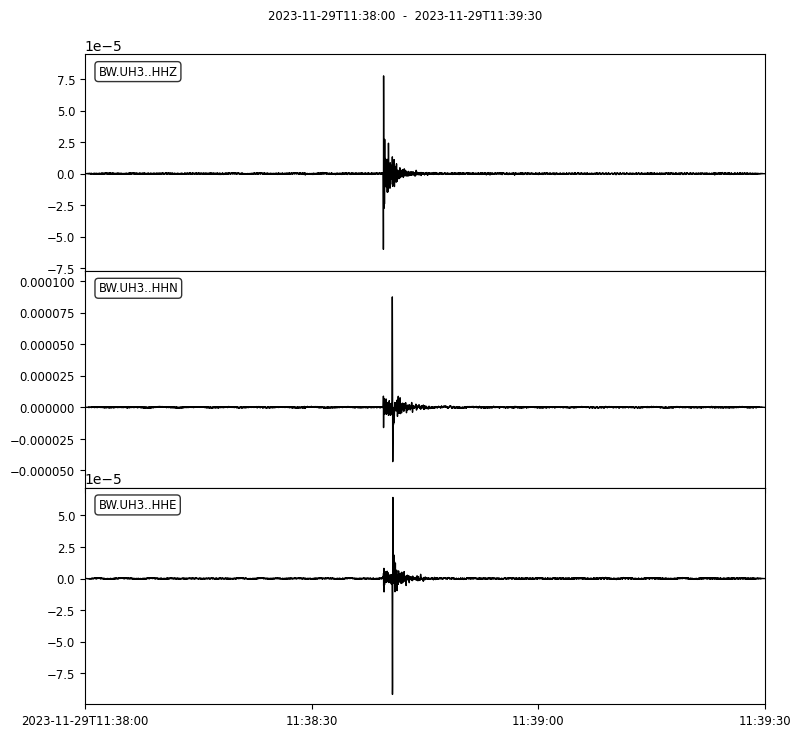

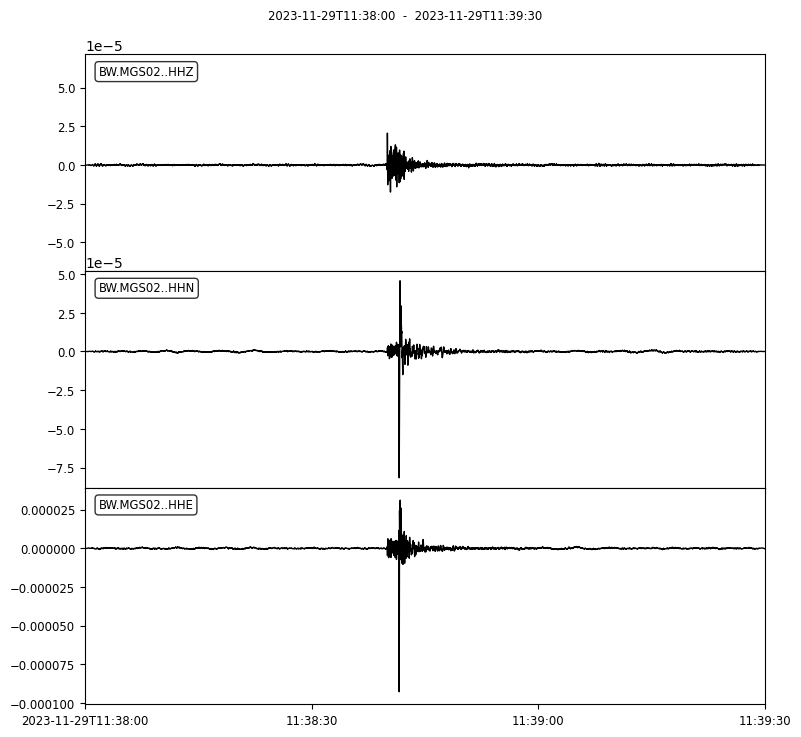

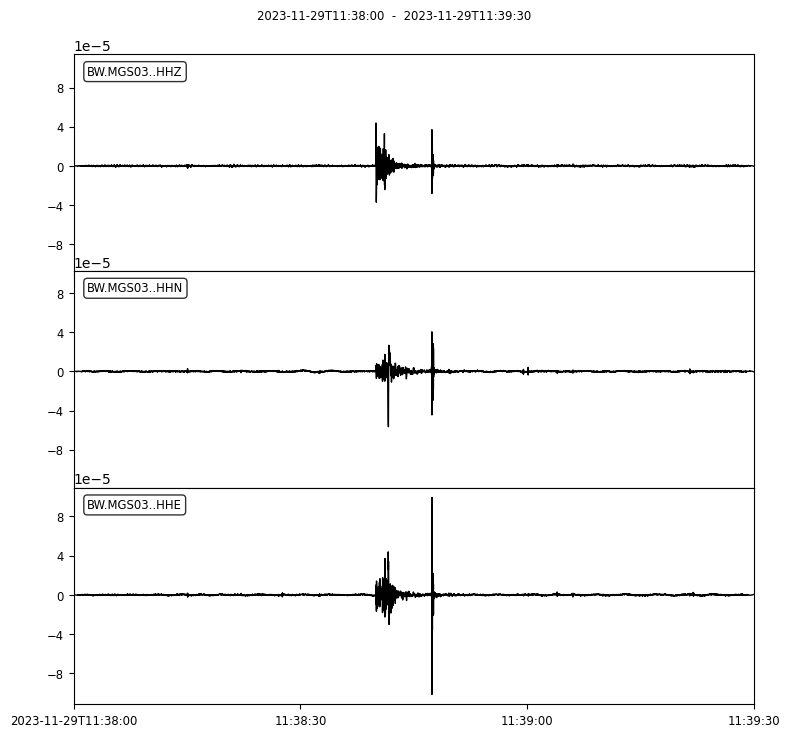

In [19]:
#preprocessing
       
#remove instrument response
st_UH3.remove_response(inventory=inv_UH3,output="VEL",water_level=False)
st_MGS02.remove_response(inventory=inv_MGS02,output="VEL",water_level=False)
st_MGS03.remove_response(inventory=inv_MGS03,output="VEL",water_level=False)

st_UH3.detrend('spline', order= 3, dspline=500)    
st_MGS02.detrend('spline', order= 3, dspline=500)
st_MGS03.detrend('spline', order= 3, dspline=500)


st_UH3.detrend("demean")
st_MGS02.detrend("demean")
st_MGS03.detrend("demean")


st_UH3.plot()
st_MGS02.plot()
st_MGS03.plot()

plt.show()

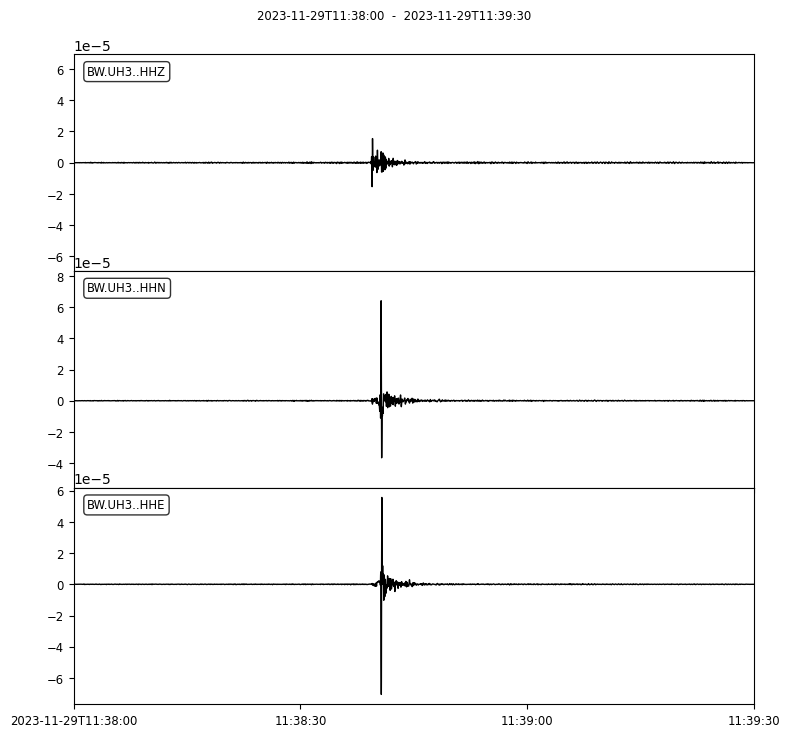

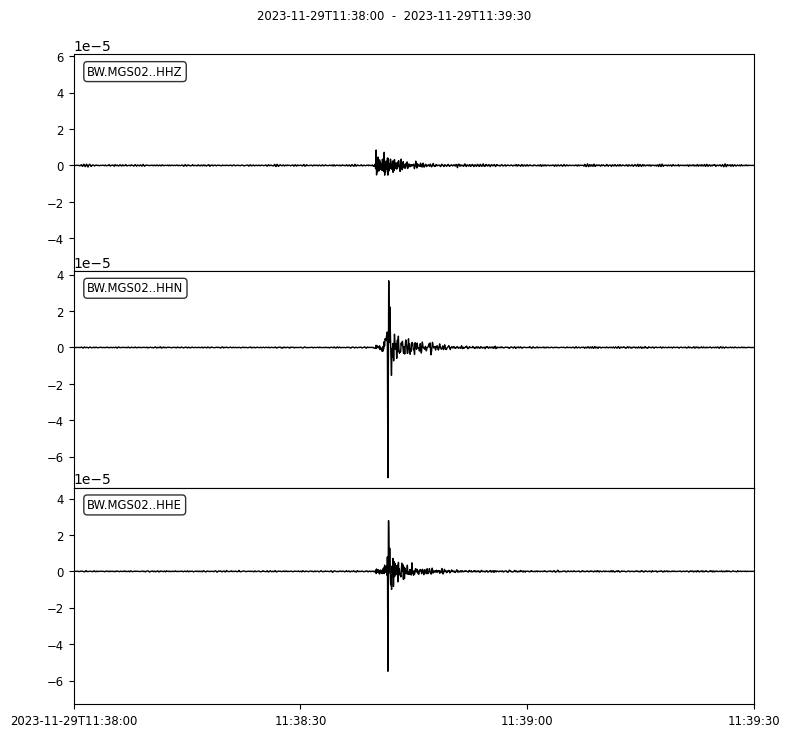

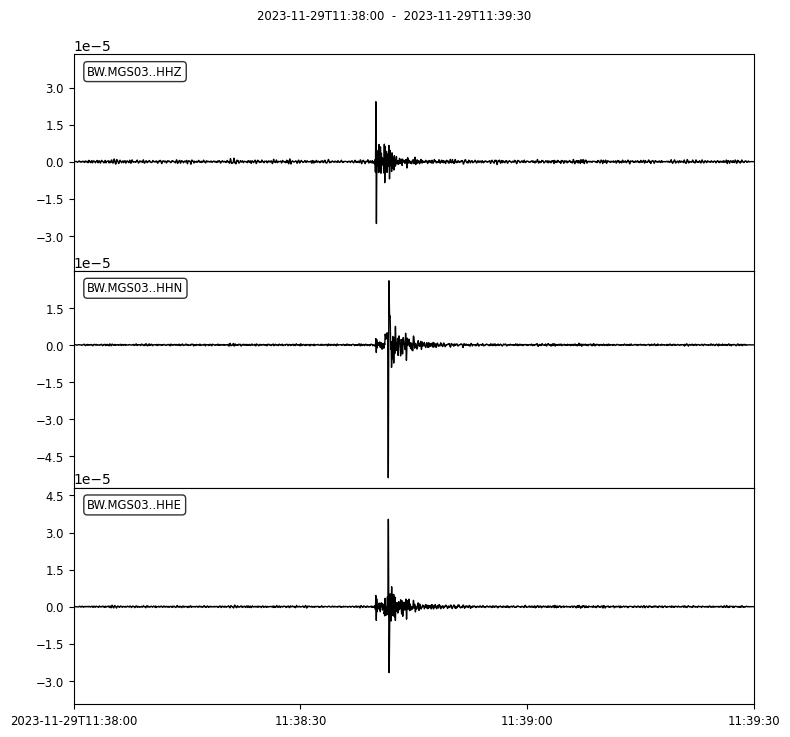

In [20]:
#Filter seismograms according to the DIN4150

freqmin=1
freqmax=10

UH3=st_UH3.copy().filter('bandpass', freqmin=freqmin,freqmax=freqmax, corners=4, zerophase=True)
MGS02=st_MGS02.copy().filter('bandpass', freqmin=freqmin,freqmax=freqmax, corners=4, zerophase=True)
MGS03=st_MGS03.copy().filter('bandpass', freqmin=freqmin,freqmax=freqmax, corners=4, zerophase=True)


UH3.plot()
MGS02.plot()
MGS03.plot()
plt.show()

In [21]:
#compute PGV value for each station

PGV_UH3=[]
for n in range(len(UH3)):
    PGV=max(abs(UH3[n].data))
    PGV_UH3.append(PGV)
    
print("The PGV values for UH3 are:", PGV_UH3, "m/s")

PGV_MGS02=[]
for n in range(len(MGS02)):
    PGV=max(abs(MGS02[n].data))
    PGV_MGS02.append(PGV)
    
print("The PGV values for MGS02 are:", PGV_MGS02, "m/s")

PGV_MGS03=[]
for n in range(len(MGS03)):
    PGV=max(abs(MGS03[n].data))
    PGV_MGS03.append(PGV)
    
print("The PGV values for MGS03 are:", PGV_MGS03, "m/s")


The PGV values for UH3 are: [1.5458681909958032e-05, 6.402758435443425e-05, 7.054357785223655e-05] m/s
The PGV values for MGS02 are: [8.465930447012756e-06, 7.160665532785579e-05, 5.490807609849553e-05] m/s
The PGV values for MGS03 are: [2.5013548739963156e-05, 5.375819275180338e-05, 3.5355536595016856e-05] m/s


In [22]:
#To compare it to the DIN we have to compute the root-mean-square value from the horizontal components

rms_UH3=np.sqrt((PGV_UH3[1]**2 + PGV_UH3[2]**2)/2)
print("UH3:", rms_UH3*1000, "mm/s")

rms_MGS02=np.sqrt((PGV_MGS02[1]**2 + PGV_MGS02[2]**2)/2)
print("MGS02:", rms_MGS02*1000, "mm/s")

rms_MGS03=np.sqrt((PGV_MGS03[1]**2 + PGV_MGS03[2]**2)/2)
print("MGS03:", rms_MGS03*1000, "mm/s")


UH3: 0.06736441172629193 mm/s
MGS02: 0.06380599465599025 mm/s
MGS03: 0.04549701779161807 mm/s


At none of the stations the PGV values exceeded 5 mm/s.

However, Keil et al. (2022) simulated induced events in Poing to see the ground motion distribution. The results show that often the recording stations do not lie in the areas of largest ground motion and therefore the peak PGV values for the events might be underestimated. This highlights the challenge of estimating affected areas in case of induced seismicity, as a dense monitoring network is neither feasible nor required by law. (The map shows the ground motion simulation and recording stations of an induced event in Poing; see Keil et al. 2022)

<figure>
  <IMG SRC="./Figures/PGV.png" WIDTH=700 ALIGN="center">
</figure>

### References

Keil, S., Wassermann, J., & Megies, T. (2022). Estimation of ground motion due to induced seismicity at a geothermal power plant near munich, germany, using numerical simulations. Geothermics, 106, 102577.